# E-Commerce Retail Business Analysis
## Python Data Analyst Assessment
## Creware Technology

### *Candidate Name:* Mohammedkaif Momin  

# 1. Business Objectives

This dataset represents a retail e-commerce business consisting of customer, product, transaction, and location data. 
The Obectives of this analysis is to evaluate sales performance, customer behaviour and operational risks using multi-files relational datasets.

This project aims to:
- Calculate core business KPIs (Revenue, Profit, Return Rate, CLV)
- Identify revenue drivers and risk areas.
- Provide data-driven Strategic recommendations

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Vizualizations
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
customers = pd.read_csv("C:\\Users\\ASUS\\Downloads\\customers.csv")
products = pd.read_csv("C:\\Users\\ASUS\\Downloads\\products.csv")
transactions = pd.read_csv("C:\\Users\\ASUS\\Downloads\\transactions.csv")
locations = pd.read_csv("C:\\Users\\ASUS\\Downloads\\locations.csv")

print("Customers:",customers.shape)
print("Products:",products.shape)
print("transactions:",transactions.shape)
print("locations:",locations.shape)

Customers: (5439, 7)
Products: (1200, 5)
transactions: (25460, 10)
locations: (15, 4)


# 2. Data Cleaning & Preparation
Data cleaning steps were performed to ensure analytical accuracy while maintaining realistic business distribution patterns across customer and transaction datasets.


### customers table

In [3]:
customers.duplicated().sum()
customers.drop_duplicates(inplace=True)

In [4]:
customers.isnull().sum()

customer_id          0
gender               0
age                  0
city                 0
signup_date          0
income             830
loyalty_segment      0
dtype: int64

Approximately 15% of income values were missing. Since income is a continuous numeric variable and likely right-skewed, missing values were imputed using the median to avoid distortion from extreme values while preserving customer records.

In [5]:
customers['income'] = pd.to_numeric(customers['income'],errors='coerce')

In [6]:
median_income = customers['income'].median()

customers.fillna({'income':median_income}, inplace=True)

Customer income data often contains extreme high-value outliers, so median provides a more stable central value compared to mean.

If missing income values are not handled, customer segmentation and purchasing power analysis would be incomplete, which can affect targeting strategies and CLV calculations.


In [7]:
customers.describe()

,age,income
count,5439.000000,5.439000e+03
mean,41.203162,8.530969e+05
std,13.488478,3.455501e+05
min,18.000000,2.000640e+05
25%,30.000000,5.948470e+05
50%,41.000000,8.545390e+05
75%,53.000000,1.116083e+06
max,64.000000,1.499825e+06


In [8]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'],errors='coerce')

Date columns were converted to datetime format to enable accurate time-based analysis and prevent string-based chronological errors.

In [9]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5439 entries, 0 to 5438
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      5439 non-null   object        
 1   gender           5439 non-null   object        
 2   age              5439 non-null   int64         
 3   city             5439 non-null   object        
 4   signup_date      5439 non-null   datetime64[ns]
 5   income           5439 non-null   float64       
 6   loyalty_segment  5439 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 297.6+ KB


### Product table

In [10]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   product_id   1200 non-null   object
 1   category     1200 non-null   object
 2   brand        1200 non-null   object
 3   cost_price   1200 non-null   int64 
 4   launch_date  1200 non-null   object
dtypes: int64(1), object(4)
memory usage: 47.0+ KB


In [11]:
products.duplicated().sum()
products.drop_duplicates(inplace=True)

In [12]:
products['launch_date'] = pd.to_datetime(products['launch_date'],errors='coerce')

Date columns were converted to datetime format to enable accurate time-based analysis and prevent string-based chronological errors.

In [13]:
products.describe()

,cost_price,launch_date
count,1200.00000,1200
mean,25081.41500,2022-01-16 05:19:12
min,159.00000,2020-01-01 00:00:00
25%,13484.25000,2021-01-14 00:00:00
50%,24584.00000,2022-02-01 12:00:00
75%,37327.25000,2023-01-20 06:00:00
max,49971.00000,2024-02-08 00:00:00
std,14274.25802,NaN


In [14]:
products.isnull().sum()

product_id     0
category       0
brand          0
cost_price     0
launch_date    0
dtype: int64

### Transaction Table

In [15]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25460 entries, 0 to 25459
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    25460 non-null  object
 1   customer_id       25460 non-null  object
 2   product_id        25460 non-null  object
 3   transaction_date  25460 non-null  object
 4   quantity          25460 non-null  int64 
 5   unit_price        25460 non-null  object
 6   discount_percent  25460 non-null  int64 
 7   payment_mode      25460 non-null  object
 8   delivery_days     25460 non-null  int64 
 9   returned          25460 non-null  object
dtypes: int64(3), object(7)
memory usage: 1.9+ MB


In [16]:
transactions.duplicated().sum()
transactions.drop_duplicates(inplace=True)

Duplicate transaction records can inflate revenue, order counts, and customer activity metrics.

If duplicates are not removed, revenue and sales KPIs will be overstated, leading to incorrect business decisions such as overstocking inventory or overestimating demand.


In [17]:
# Converting unit price object into integer.

transactions['unit_price'] = (
    transactions['unit_price']
    .replace('[₹,]', '', regex=True)
)

transactions['unit_price'] = pd.to_numeric(
    transactions['unit_price'],
    errors='coerce'
)

The unit_price column was stored as text due to currency symbols and formatting characters, which prevented mathematical operations.

Without converting unit price to numeric format, revenue and profit calculations would be inaccurate or fail during computation, leading to unreliable financial reporting.These were removed using regex and converted to float for accurate revenue computation.



In [18]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date'],
    errors='coerce'
)

Date columns were converted to datetime format to enable accurate time-based analysis and prevent string-based chronological errors.

In [19]:
transactions.describe()

,transaction_date,quantity,unit_price,discount_percent,delivery_days
count,25460,25460.000000,25460.000000,25460.000000,25460.000000
mean,2023-01-01 04:35:02.875097856,48.237706,25034.193637,19.398979,4.322742
min,2022-01-01 00:00:00,1.000000,200.000000,0.000000,-3.000000
25%,2022-07-02 00:00:00,1.000000,12597.000000,10.000000,1.000000
50%,2023-01-03 00:00:00,2.000000,24923.500000,19.000000,4.000000
75%,2023-07-03 00:00:00,4.000000,37510.500000,29.000000,7.000000
max,2024-01-01 00:00:00,1000.000000,50000.000000,39.000000,10.000000
std,NaN,208.799664,14379.017664,11.501514,3.748312


In [20]:
transactions[transactions['delivery_days']<0].shape

(2136, 10)

In [21]:
neg_count = transactions[transactions['delivery_days'] < 0].shape[0]
total_count = transactions.shape[0]

neg_count, total_count, (neg_count/total_count)*100

(2136, 25460, 8.389630793401412)

In [22]:
# In delivery days 8.3% days are in negative so i changed them to median delivery days.

transactions.loc[
    transactions['delivery_days'] < 0,
    'delivery_days'
] = np.nan

median_days = transactions['delivery_days'].median()

transactions.fillna({'delivery_days':median_days}, inplace=True)
transactions['delivery_days'].describe()

count    25460.000000
mean         4.993912
std          3.023067
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: delivery_days, dtype: float64

Approximately 8.3% of delivery_days values were negative, which is logically inconsistent. As delivery_date was not available for recalculation, these were treated as data errors. To avoid losing transaction records, the invalid values were replaced with the median delivery time.

If not corrected, delivery performance metrics would be distorted, affecting logistics performance analysis and customer experience evaluation.


In [23]:
transactions.isnull().sum()

transaction_id      0
customer_id         0
product_id          0
transaction_date    0
quantity            0
unit_price          0
discount_percent    0
payment_mode        0
delivery_days       0
returned            0
dtype: int64

In [24]:
transactions.describe()

,transaction_date,quantity,unit_price,discount_percent,delivery_days
count,25460,25460.000000,25460.000000,25460.000000,25460.000000
mean,2023-01-01 04:35:02.875097856,48.237706,25034.193637,19.398979,4.993912
min,2022-01-01 00:00:00,1.000000,200.000000,0.000000,0.000000
25%,2022-07-02 00:00:00,1.000000,12597.000000,10.000000,3.000000
50%,2023-01-03 00:00:00,2.000000,24923.500000,19.000000,5.000000
75%,2023-07-03 00:00:00,4.000000,37510.500000,29.000000,7.000000
max,2024-01-01 00:00:00,1000.000000,50000.000000,39.000000,10.000000
std,NaN,208.799664,14379.017664,11.501514,3.023067


### Location Table

In [25]:
locations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   city        15 non-null     object
 1   state       15 non-null     object
 2   region      15 non-null     object
 3   population  15 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 612.0+ bytes


In [26]:
locations.duplicated().sum()
locations.drop_duplicates(inplace=True)

In [27]:
locations['city'].unique()
locations.shape

(15, 4)

In [28]:
locations.isnull().sum()

city          0
state         0
region        0
population    0
dtype: int64

## Cleaning Details

Data cleaning was performed to improve dataset reliability and ensure accurate downstream analysis. Missing income values in the customer dataset were handled using median imputation to maintain realistic income distribution without being affected by extreme outliers.

The unit_price column required preprocessing as it contained currency symbols and formatting characters. These were removed using regex and converted into numeric format to enable accurate revenue and profit calculations.

Delivery_days contained logically invalid negative values, which were replaced using the median delivery duration calculated from valid records to maintain realistic logistics performance patterns.

Post-cleaning validation checks were performed to confirm removal of missing values, correction of invalid entries, and readiness of the dataset for merging and KPI computation.


# 3.Data Merging & Integration

## Overview
To perform meaningful business analysis, multiple datasets were integrated into a single analytical table. The objective was to create a unified dataset containing transactional, customer, product, and location-level attributes.

The integration was performed using Pandas merge operations, treating the transactions dataset as the primary fact table.

## Merge Approach

### 1. Transactions with Customers
The first step was merging transaction data with customer attributes using the `customer_id` column.

A left join was used to ensure that all transaction records were preserved, even if some customer attributes were missing. This is critical for maintaining revenue completeness.


In [29]:
merged_df = transactions.merge(customers, on='customer_id', how='left')

### 2. Adding Product Information
Next, product-level details such as cost price were added using the `product_id` key.

This merge enabled calculation of important metrics such as:
- Unit margin
- Profit per transaction
- Profitability analysis

A left join ensured that no transactions were dropped due to missing product metadata.

In [30]:
merged_df = merged_df.merge(products, on='product_id', how='left')

### 3. Integrating Location Data
Finally, geographic information was merged using the `city` column.

Since a dedicated location ID was unavailable, city name was used as a surrogate join key. This allowed enrichment of transactions with regional insights while preserving row integrity.


In [31]:
merged_df = merged_df.merge(locations, on='city', how='left')

## Join Strategy Justification
Left joins were consistently used because:

- Transactions are the primary analytical unit  
- Revenue loss due to row drops must be avoided  
- Financial metrics must remain unbiased  
- Analytical completeness is more important than strict relational matching  

Using inner joins could have resulted in:
- Dropped transactions  
- Underreported revenue  
- Incorrect profitability insights  


## Data Integrity Validation
After merging:
- Row count remained constant (~25K transactions)
- No duplication introduced
- All dimension attributes successfully appended

This confirms that the integration process preserved both data completeness and analytical accuracy.

---

## Outcome
The final merged dataset contains:

- Transactional metrics (revenue, profit, discount)
- Customer attributes
- Product cost structure
- Geographic context

This unified dataset serves as the foundation for:
- Profitability analysis  
- Customer Lifetime Value (CLV)  
- Return impact analysis  
- Business visualizations

In [32]:
merged_df.shape

(25460, 23)

In [33]:
merged_df

,transaction_id,customer_id,product_id,transaction_date,quantity,unit_price,discount_percent,payment_mode,delivery_days,returned,...,signup_date,income,loyalty_segment,category,brand,cost_price,launch_date,state,region,population
0,TXN000001,CUST04835,PROD0883,2022-03-15,2,35143,16,UPI,2.0,No,...,2021-04-17,813517.0,Silver,Fashion,BrandD,12982,2022-01-07,Delhi,North,19000000
1,TXN000002,CUST02792,PROD0907,2022-03-19,1,27217,27,UPI,0.0,No,...,2022-12-25,396979.0,Regular,Grocery,BrandB,10319,2020-02-11,Maharashtra,West,20000000
2,TXN000003,CUST05424,PROD0738,2023-09-26,2,13363,1,UPI,0.0,No,...,2021-03-21,1313650.0,Platinum,Fashion,BrandC,32625,2022-12-13,Telangana,South,10000000
3,TXN000004,CUST04213,PROD0127,2023-04-04,1,2258,39,UPI,10.0,No,...,2021-01-14,854539.0,Silver,Electronics,BrandB,45619,2023-03-10,Maharashtra,West,7000000
4,TXN000005,CUST03984,PROD1140,2023-06-24,5,41453,36,UPI,3.0,No,...,2023-07-21,854539.0,Silver,Home,BrandC,21420,2020-05-21,Maharashtra,West,7000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25455,TXN025456,CUST00010,PROD0820,2022-11-06,1,40459,10,Wallet,2.0,Yes,...,2023-08-05,1016445.0,Regular,Fashion,BrandB,18017,2020-09-28,Maharashtra,West,20000000
25456,TXN025457,CUST03099,PROD1101,2023-06-04,5,22314,4,Wallet,10.0,Yes,...,2023-01-09,1077944.0,Regular,Home,BrandA,24723,2022-04-25,Maharashtra,West,20000000
25457,TXN025458,CUST02817,PROD0480,2022-01-25,2,25844,13,Wallet,10.0,Yes,...,2021-06-25,896480.0,Regular,Electronics,BrandD,1678,2023-04-02,Maharashtra,West,20000000
25458,TXN025459,CUST00327,PROD0284,2023-08-22,3,21893,28,Wallet,2.0,Yes,...,2021-07-27,854539.0,Regular,Electronics,BrandB,6189,2023-04-21,Maharashtra,West,20000000


In [34]:
merged_df.to_csv("cleaned_merged_data.csv", index=False)

### Final Cleaned merged Dataset

All datasets were cleaned and merged into a single analytical table using LEFT JOINs with transactions as the base table. This ensures that all transactional records are preserved while enriching them with customer, product, and location attributes.

The final dataset includes:
- Cleaned data types
- Handled missing values
- Engineered business metrics (Revenue, Profit, Margin)
- No duplicate records

This dataset is analysis-ready and suitable for downstream reporting and visualization.

# 4. Feature Engineering

Created new metrics:
- Revenue
- Gross Revenue
- Total Cost
- Profit
- Profit Margin
- Unit Margin

### Revenue
Revenue is calculated as (Quantity × Unit Price)*(1-discount percent/100). It is assumed that unit price represents the actual selling price recorded at the transaction level after any applied pricing adjustments available in the dataset.


In [205]:
merged_df['revenue'] = (merged_df['quantity']*merged_df['unit_price']*(1-merged_df['discount_percent']/100))

In [206]:
merged_df['revenue'].describe()

count    2.546000e+04
mean     9.446099e+05
std      4.797298e+06
min      1.335600e+02
25%      1.873039e+04
50%      3.757537e+04
75%      7.693276e+04
max      4.905252e+07
Name: revenue, dtype: float64

### Gross Revenue
Gross Revenue represents total sales value before considering returns or refunds. It is assumed that all completed transactions contribute positively to gross revenue regardless of later return status.


In [207]:
merged_df['gross_revenue']=(merged_df['quantity']*merged_df['unit_price'])

In [208]:
merged_df['gross_revenue'].sum()

np.int64(30127071628)

### Total Cost 
Total Cost is assumed to represent direct product-level cost such as procurement or manufacturing cost. Since operational costs like marketing, warehousing, or logistics are not available, they are excluded from cost calculations.


In [209]:
merged_df['total_cost']=(merged_df['quantity']*merged_df['cost_price'])

In [210]:
merged_df['total_cost'].describe()

count    2.546000e+04
mean     1.180388e+06
std      5.931250e+06
min      1.590000e+02
25%      2.380800e+04
50%      4.675600e+04
75%      9.399000e+04
max      4.997100e+07
Name: total_cost, dtype: float64

### Profit
Profit is calculated as Total Revenue – Total Cost. This assumes cost values provided in the dataset are accurate and directly attributable to each transaction.

In [211]:
merged_df['profit']=(merged_df['revenue']-merged_df['total_cost'])

In [212]:
merged_df['profit'].describe()

count    2.546000e+04
mean    -2.357783e+05
std      4.044060e+06
min     -4.818964e+07
25%     -3.850802e+04
50%     -8.948540e+03
75%      1.653876e+04
max      3.981952e+07
Name: profit, dtype: float64

In [213]:
merged_df['profit'].sum()

np.float64(-6002914913.400001)

### Profit margin
Profit Margin is calculated as (Profit ÷ Total Revenue) × 100. This assumes revenue values are non-zero and represent realized sales after return adjustments.


In [214]:
profit_margin = (merged_df["profit"].sum() / merged_df["revenue"].sum())*100
profit_margin

np.float64(-24.960386146659562)

### Unit Margin
Unit Margin is calculated as Unit Price – Cost price. This assumes unit cost reflects actual per-unit procurement or production cost without additional overhead allocation.


In [215]:
merged_df['unit_margin'] = (merged_df['unit_price']-merged_df['cost_price'])
merged_df['unit_margin'].describe()

count    25460.000000
mean        71.962490
std      20113.717523
min     -49187.000000
25%     -14171.000000
50%        193.000000
75%      14508.500000
max      49382.000000
Name: unit_margin, dtype: float64

These assumptions were defined to maintain consistency in financial reporting and to align metric calculations with standard retail business performance measurement practices.


### Loss Transactions in percentage

In [216]:
loss_transactions = (merged_df['unit_margin']<0).sum()
total_transactions=len(merged_df)
(loss_transactions/total_transactions)*100

np.float64(49.61901021209741)

A significant proportion of transactions were executed below cost price, resulting in negative overall profitability. This indicates pricing inefficiencies or excessive discounting strategies that require urgent review.

### Interpretation

The business generated ₹24.05B in revenue but incurred a net loss of ₹6.00B, resulting in a negative profit margin of -24.96%.  
This indicates structural pricing inefficiencies.
Nearly 49.6% of transactions were executed below cost price, leading to an overall negative profit margin of -24.96%. This indicates significant pricing inefficiencies or excessive discounting strategies. If sustained, this pricing structure threatens long-term financial sustainability.

# 5. Overall Business Performance

## Revenue trend over time

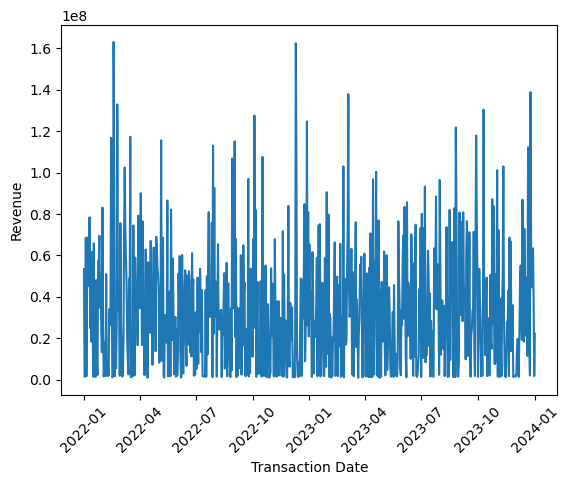

In [217]:
revenue_trend = merged_df.groupby('transaction_date')['revenue'].sum().reset_index()
plt.plot(revenue_trend['transaction_date'], revenue_trend['revenue'])
plt.xlabel("Transaction Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Revenue shows frequent spikes over time, indicating fluctuating demand patterns rather than steady growth. This suggests the business may be influenced by seasonal demand, promotional campaigns, or bulk purchase behavior.
Revenue is highly variable across time, with multiple peak periods. This indicates inconsistent demand cycles and potential reliance on campaign-driven or seasonal sales spikes.

## Revenue vs Profit By Caregory

In [218]:
merged_df.groupby('category')[['revenue','profit']].sum()

,revenue,profit
category,,
Electronics,1.178853e+10,-3.676351e+09
Fashion,6.649320e+09,-1.249018e+09
Grocery,3.254888e+09,-7.881527e+08
Home,2.357031e+09,-2.893940e+08


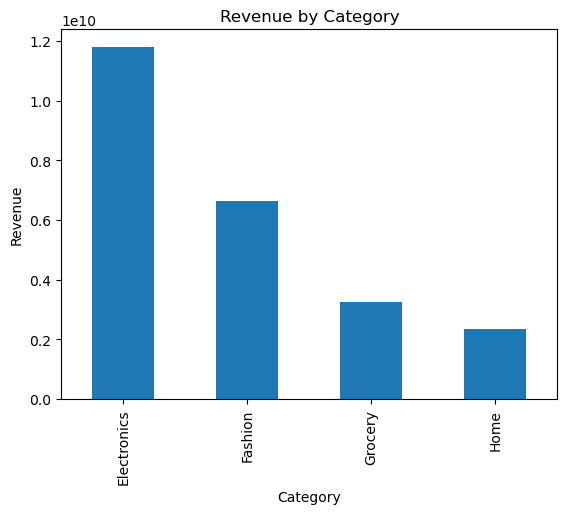

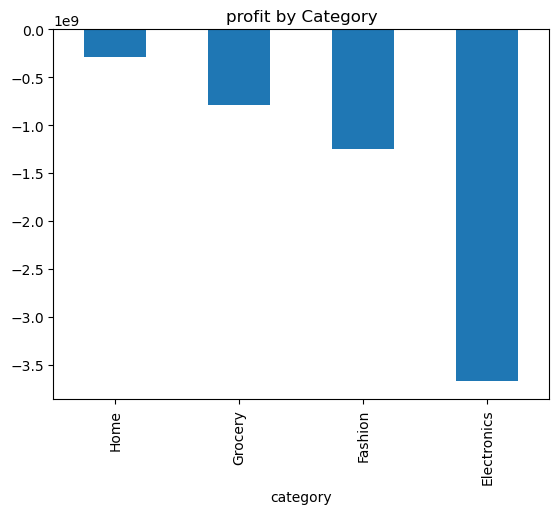

In [219]:
category_rev = merged_df.groupby("category")["revenue"].sum().sort_values(ascending=False)
category_rev.plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()
category_rev = merged_df.groupby("category")["profit"].sum().sort_values(ascending=False)
category_rev.plot(kind="bar")
plt.title("profit by Category")
plt.show()

Electronics generates the highest revenue but also shows the largest losses, indicating pricing or cost structure issues. Similar loss patterns across other categories suggest a broader profitability problem rather than category-specific issues.
All categories are generating revenue but operating at a loss, especially Electronics and Fashion. This indicates possible over-discounting, high procurement costs, or inefficient pricing strategies affecting overall profitability.

## Top Cities by Revenue

In [220]:
city_rev = merged_df.groupby("city")["revenue"].sum().sort_values(ascending=False)
city_rev.head(10)

city
Mumbai       1.403691e+10
Pune         4.955651e+09
Delhi        2.423126e+09
Bangalore    7.303802e+08
Hyderabad    6.684116e+08
Chennai      6.349386e+08
Nagpur       6.003530e+08
Name: revenue, dtype: float64

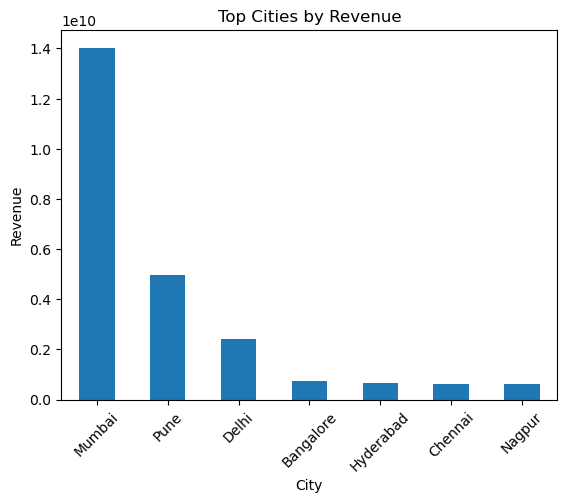

In [221]:
city_revenue = merged_df.groupby('city')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure()
city_revenue.plot(kind='bar')
plt.title("Top Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Mumbai is driving the majority of revenue compared to other cities, which shows strong market demand in this region. However, this also creates dependency risk, so expanding performance in mid-tier cities like Pune and Delhi could help stabilize revenue growth.
Targeted regional marketing and inventory optimization in high-performing cities can accelerate growth, while performance gap analysis can help improve weaker markets.

## Returned Rate

In [222]:
return_rate = merged_df['returned'].value_counts(normalize=True)*100
return_rate

returned
No     85.0
Yes    15.0
Name: proportion, dtype: float64

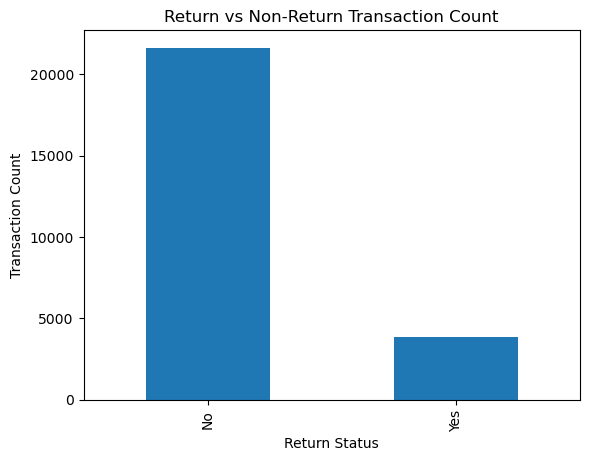

In [223]:
return_analysis = merged_df.groupby('returned')['transaction_id'].count()

plt.figure()
return_analysis.plot(kind='bar')
plt.title("Return vs Non-Return Transaction Count")
plt.xlabel("Return Status")
plt.ylabel("Transaction Count")
plt.show()


Return rate is around 15%, which is slightly on the higher side for retail operations. This suggests possible issues in product quality, delivery handling, or customer expectation mismatch

## Customer Lifetime Value (clv)

In [224]:
clv = (merged_df.groupby('customer_id')['revenue'].sum().reset_index())
clv.rename(columns={'revenue':'customer_lifetime_value'},inplace=True)
clv.sort_values('customer_lifetime_value',ascending=False).head(10)

,customer_id,customer_lifetime_value
4966,CUST05005,81165671.36
2062,CUST02079,78381394.40
4743,CUST04779,76167066.74
2125,CUST02143,74348303.04
5322,CUST05364,71908195.59
2359,CUST02378,69696797.83
2075,CUST02092,68486102.32
1096,CUST01104,65621991.14
334,CUST00337,65530180.00
1808,CUST01823,65053989.61


In [225]:
top_10_percent = clv['customer_lifetime_value'].quantile(0.9)
high_value_customers = clv[clv['customer_lifetime_value'] >= top_10_percent]
(high_value_customers['customer_lifetime_value'].sum() / clv['customer_lifetime_value'].sum()) * 100

np.float64(73.32223467871235)

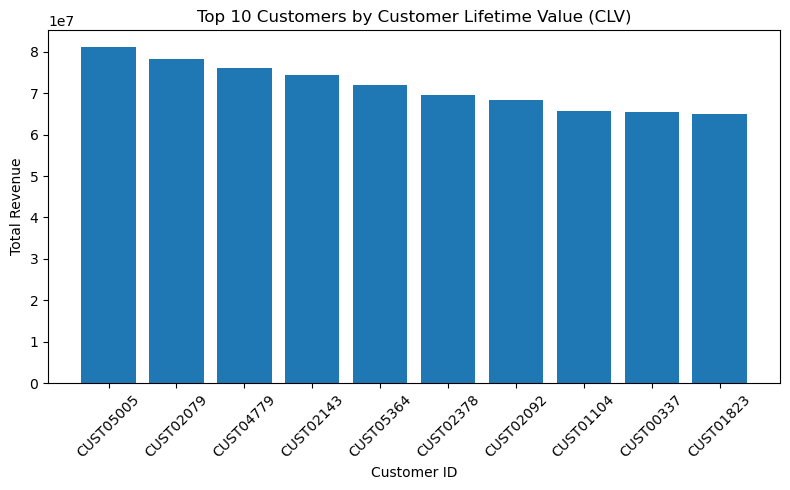

In [226]:
clv = (merged_df.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(8, 5))
plt.bar(clv.index.astype(str), clv.values)

plt.title('Top 10 Customers by Customer Lifetime Value (CLV)')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The top 10 customers contribute significantly to overall revenue.
These high-value customers should be targeted with retention strategies, loyalty programs, and personalized offers to maximize long-term profitability.
Around 73% of total revenue comes from the top 10 customers, indicating the business is highly dependent on a small high-value customer group. Strengthening retention strategies for these customers is critical for revenue stability.

## Discount Affect on Profit

In [230]:
correlation = merged_df['discount_percent'].corr(merged_df['profit'])
print("Correlation between Discount and Profit:", correlation)

Correlation between Discount and Profit: -0.023811317181177457


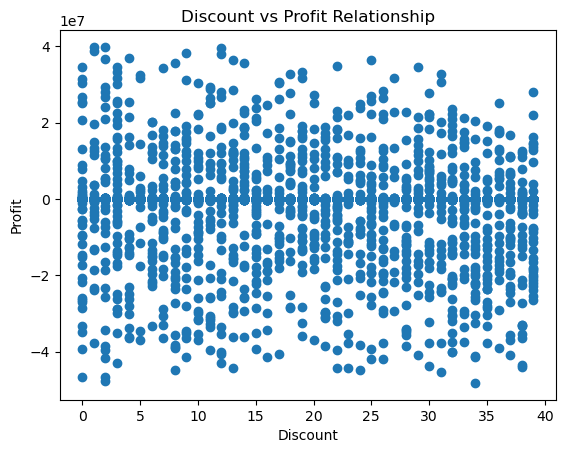

In [227]:
plt.scatter(merged_df['discount_percent'], merged_df['profit'])
plt.title("Discount vs Profit Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()


The scatter pattern shows that as discount increases, profit tends to decline. This suggests that discount strategies may be driving sales volume but hurting margin performance.

Analysis indicates that aggressive discounting is contributing to revenue generation but is also impacting overall profitability. A significant portion of transactions are occurring at reduced margins, and in some cases below cost, suggesting lack of discount governance.

While discounts may be driving short-term sales volume, they are negatively affecting long-term profitability sustainability.

Implementing controlled discount strategies and minimum margin thresholds can help balance revenue growth with sustainable profitability.


## Overall Business Story

The analysis indicates that while the business is generating strong revenue volumes, overall profitability is being negatively impacted due to pricing inefficiencies, high return-related losses, and margin pressure across certain product categories.

Revenue is highly concentrated among a small group of high-value customers, which creates both an opportunity for focused retention strategies and a potential risk if customer churn occurs within this segment. Customer purchasing behavior suggests strong repeat potential, indicating scope for loyalty-driven growth.

From an operational perspective, high return rates are significantly increasing loss exposure, especially where returned transactions are associated with higher cost absorption and reverse logistics overhead. This highlights potential quality control or product expectation gaps that need to be addressed.

Location-level analysis shows uneven regional performance, suggesting that demand strength is not uniform across markets. This presents opportunities for targeted expansion in high-performing cities and performance improvement strategies in weaker regions.

Additionally, discount-driven sales appear to be contributing to revenue growth but are simultaneously reducing profit margins, indicating a need for controlled discounting frameworks and pricing optimization strategies.

Overall, the business shows strong market demand and customer engagement potential, but requires structured pricing controls, return reduction strategies, and product profitability optimization to achieve sustainable long-term profitability.


# 6. Key Findings & Strategic Recommendations

## Operational Risk Indicators
- High return rate categories
- Revenue concentration among top customers
- Cities with low profitability

## Key Insights

1. Customer Revenue Concentration Risk Revenue is highly concentrated, with the top 10% of customers contributing 73.32% of total revenue. This creates a dependency risk where losing a small number of customers could significantly impact total revenue stability.
2. Margin Leakage in High-Revenue Categories Certain product categories generate strong revenue but operate at low or negative margins, indicating misaligned pricing strategy or high supply chain cost burden.
3. Regional Performance Imbalance City-level revenue distribution shows uneven performance, suggesting opportunities for targeted regional marketing and supply chain optimization.
4. Structural Profitability Issue. The business is currently operating at a -24.96% overall profit margin, indicating systemic pricing, discounting, or cost management inefficiencies rather than isolated product-level losses.
5. Below-Cost Selling Risk Approximately 49.6% of transactions are sold below cost, directly driving negative profitability and indicating urgent need for pricing policy review and discount governance.
6. High Return-Driven Loss Exposure Returned transactions generate significantly higher losses (avg -₹227K) compared to non-returned transactions (avg -₹6K), suggesting operational inefficiencies in product quality, description accuracy, or logistics handling.
7. Return Rate Risk Indicator The overall return rate of 15% is at the upper threshold of acceptable retail benchmarks and may lead to long-term cost escalation if not addressed.
   





## Recommendations

Short-Term:(0-3 months)
- Strengthen Quality Control in High-Return Categories
Focus inspection and vendor quality audits on high-return products to reduce reverse logistics cost and customer dissatisfaction.
-  High-Value Customer Retention Program
Deploy loyalty programs, personalized offers, and premium support for top 10% revenue customers to reduce churn risk and stabilize revenue streams
- Implement Pricing Control Framework
Introduce minimum margin thresholds and automated discount monitoring to reduce below-cost selling and improve gross profitability.

Long-Term:(3-12 months)
- Expand in High-Performing Cities
Increase marketing investment, warehousing efficiency, and inventory availability in top-performing cities to accelerate profitable revenue growth.
- Product Portfolio Profitability Optimization
  Re-evaluate low-margin product lines by:

  1.Renegotiating supplier costs

  2.Adjusting pricing strategy

  3.Phasing out consistently loss-making SKUs

- Returns Reduction Strategy
  Invest in:

  1.Better product descriptions

  2.Improved product imagery

  3.Customer expectation management

  4.Packaging and logistics improvement

## Limitations
- City-based merging may introduce minor mapping inaccuracies
- No seasonal time-series analysis included
- Lack of demographic variables.